Linear Regression

Linear Regression is a supervised learning algorithm used to model the relationship between a dependent variable and one or more independent variables by fitting a linear equation to the data. It assumes that the target variable can be expressed as a weighted sum of the input features, making it a simple, interpretable, and widely used method for regression problems.

In this project, Linear Regression is applied to a real estate dataset to predict house prices based on several numerical features, including transaction date, house age, distance to the nearest MRT station, number of convenience stores, latitude, and longitude. The task involves learning how these features influence house prices and estimating the corresponding coefficients that define their impact. Once trained, the model can predict prices for new data points, providing insights into how different factors contribute to property valuation.

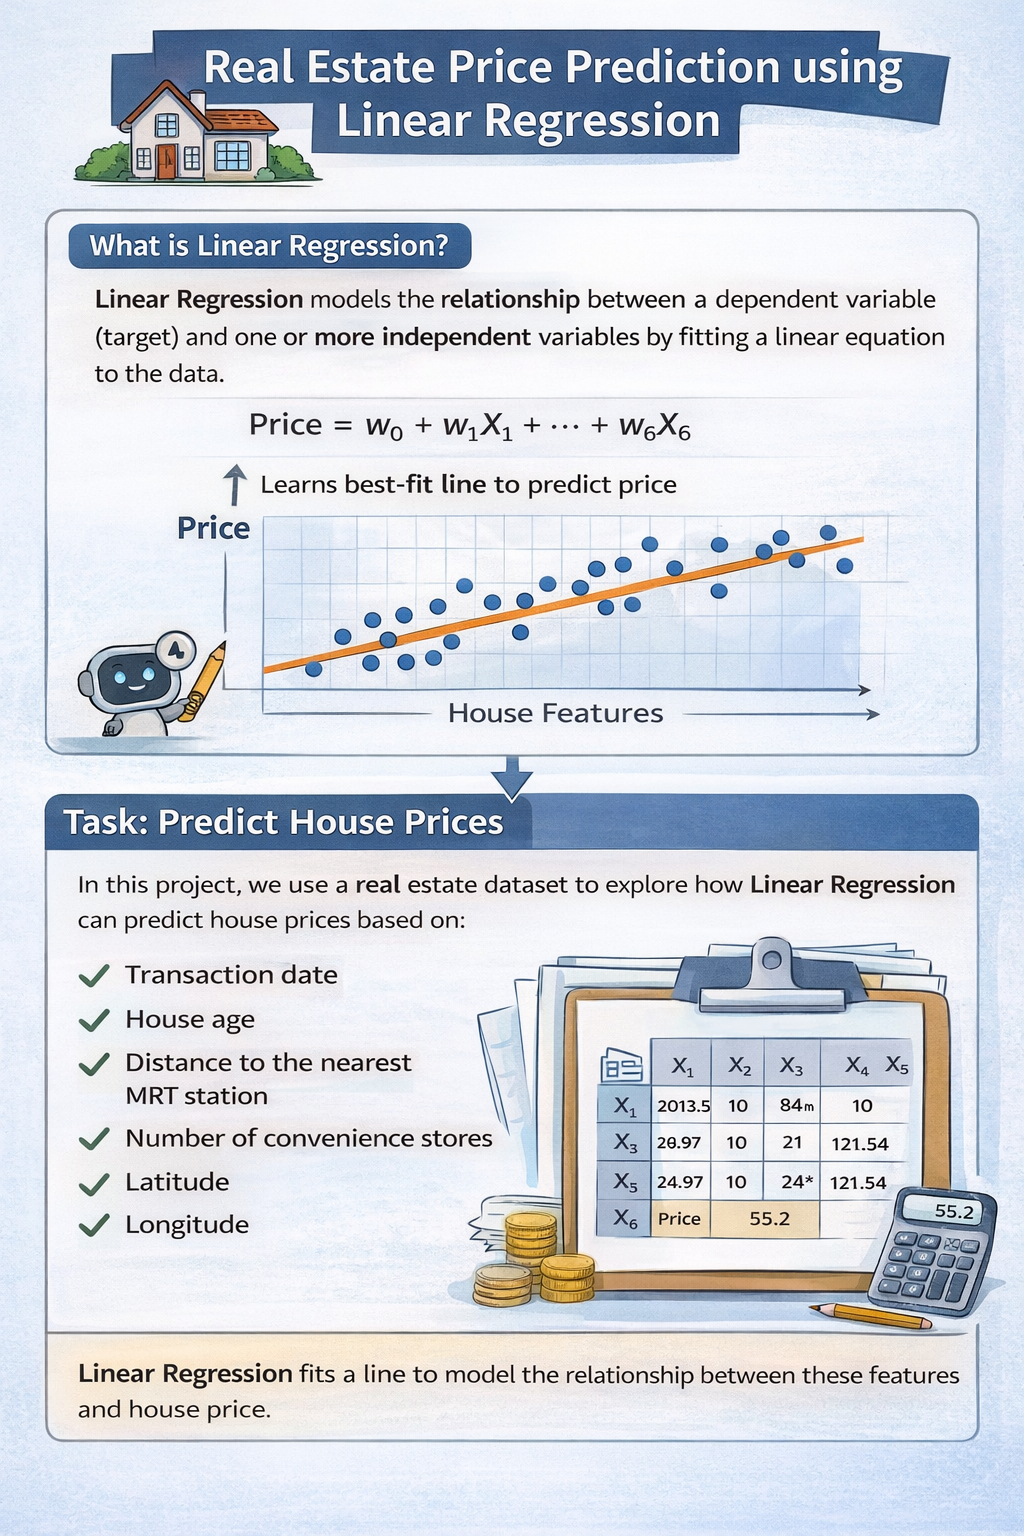

This notebook demonstrates a complete Linear Regression workflow for real estate price prediction, including loading and inspecting the dataset, preparing features and the target variable, performing a train–test split, building the model using scikit-learn, and evaluating performance using RMSE and R². It also includes visualizations such as actual vs. predicted values and residual plots to assess model accuracy. Linear Regression is appropriate for this task since the target variable (price) is continuous, the input features are numerical, and their relationship can be reasonably approximated as linear. During dataset inspection, the data is loaded into a pandas DataFrame, explored using head() to view sample records, analyzed with info() to understand data types and structure, and summarized using describe() to examine distributions and identify potential anomalies.

In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("/content/Real-estate-dataset.csv")

# Inspect data
print(df.head())
print(df.info())
print(df.describe())

   price  No  X1 transaction date  X2 house age  \
0   37.9   1             2012.917          32.0   
1   42.2   2             2012.917          19.5   
2   47.3   3             2013.583          13.3   
3   54.8   4             2013.500          13.3   
4   43.1   5             2012.833           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  
0     24.98298     121.54024  
1     24.98034     121.53951  
2     24.98746     121.54391  
3     24.98746     121.54391  
4     24.97937     121.54245  
<class 'pandas.core.frame.DataFrame'>


Feature Selection and Target Variable

During preprocessing, the “No” column is removed as it serves only as an index and does not contribute to predictive modeling. The dataset is then split into input features and the target variable: “price” is assigned as the target (y), while all remaining relevant columns are used as features (X) for training the model.

In [2]:
# Remove index column
df = df.drop(columns=["No"])

# Define target and features
y = df["price"]
X = df.drop(columns=["price"])

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245



Target:


,price
0,37.9
1,42.2
2,47.3
3,54.8
4,43.1


Train/Test Split

The dataset is divided into two subsets to ensure reliable model evaluation. The training set is used to fit and learn the model parameters, while the test set is reserved for evaluating performance on unseen data. This separation helps assess the model’s ability to generalize beyond the data it was trained on.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 331
Test samples: 83


In [5]:
#Train the Model
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

print("Intercept:", lin_reg.intercept_)
print("Coefficients:")
for feature_name, coef in zip(X.columns, lin_reg.coef_):
    print(f"{feature_name}: {coef:.4f}")


Intercept: -13044.231917160534
Coefficients:
X1 transaction date: 5.4407
X2 house age: -0.2708
X3 distance to the nearest MRT station: -0.0048
X4 number of convenience stores: 1.0914
X5 latitude: 229.0431
X6 longitude: -29.4926


In [7]:
#Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² score: {r2:.3f}")

RMSE: 7.31
R² score: 0.681


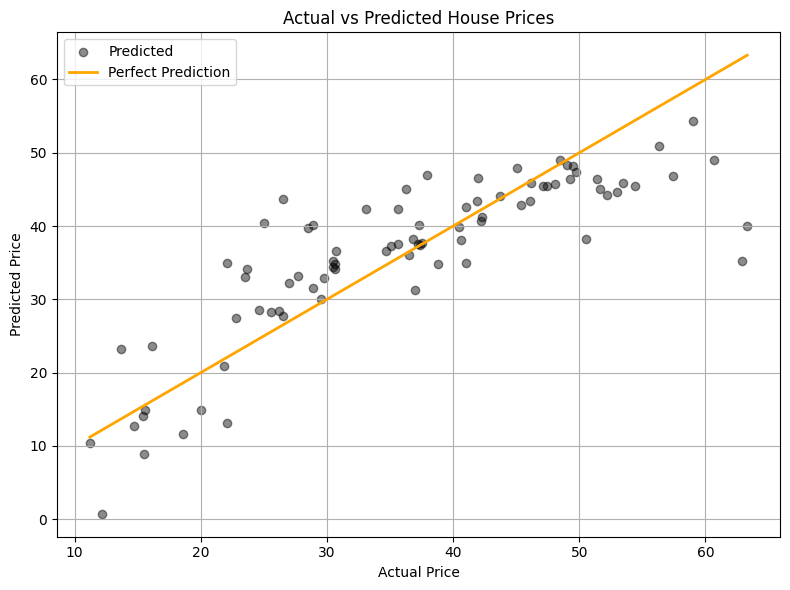

In [12]:
import matplotlib.pyplot as plt

def plot_predictions(y_true, y_pred):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.45, color="black", label="Predicted")
    plt.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="orange",
        linewidth=2,
        label="Perfect Prediction"
    )
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title("Actual vs Predicted House Prices")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_predictions(y_test, y_pred)

Visualization: Residual Plot

Residuals are computed as the difference between actual and predicted values to quantify model error. These residuals are plotted against predicted prices to analyze error distribution and detect patterns. A horizontal reference line at zero is included to distinguish between overestimation and underestimation. Visual clarity is enhanced using point transparency, along with labeled axes, titles, gridlines, and proper layout formatting. This plot is essential for diagnosing issues such as bias, non-linearity, or heteroscedasticity in the model’s predictions.

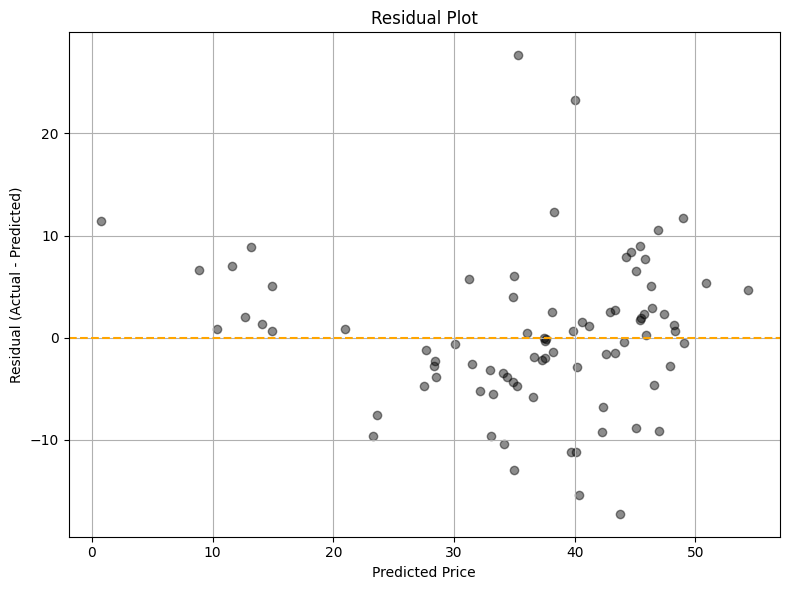

In [13]:
def plot_residuals(y_true, y_pred):
    residuals = y_true - y_pred
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, residuals, alpha=0.45, color="black")
    plt.axhline(0, color="orange", linestyle="--")
    plt.xlabel("Predicted Price")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title("Residual Plot")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_residuals(y_test, y_pred)

Final Conclusion

The residual plot indicates that the differences between actual and predicted house prices are generally centered around the zero line, suggesting that the linear regression model does not exhibit significant systematic bias. The residuals appear randomly distributed; however, a slight increase in spread at higher predicted values indicates the presence of heteroscedasticity, meaning the model’s accuracy decreases for higher-priced properties. Additionally, a few distant points from the zero line suggest the presence of outliers or observations not well captured by the linear model. Overall, while the randomness of residuals supports the suitability of linear regression, the increasing variance at higher values implies that more complex models, such as polynomial or tree-based approaches, may provide improved performance.